# App-31 — RCPSP/max : quand la faisabilité devient le problème

## Décalages généralisés, circuits de poids positif, et ce qu'une borne gratuite dit d'un banc d'essai

Cette application prolonge le projet **B4 — Ordonnancement industriel** d'**Arthur Gallier** et
**Nicolas Naegelen** (EPITA SCIA, Programmation par Contraintes 2026,
[PR #51](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/pull/51),
commit `8b91a736`).

Leur rendu réunit un parseur PSPLIB écrit à la main, un modèle CP-SAT du RCPSP, une baseline
génétique à croisement préservant les précédences, un banc d'essai sur j30/j60/j120, une étude
de stratégies de branchement, une ouverture RCPSP/max et une ouverture multi-mode. C'est ce
geste — poser côte à côte l'exact et l'approché sur un benchmark public — que ce notebook
prolonge.

Il le prolonge sur un point précis. La section RCPSP/max du rendu pose le bon modèle général,
par décalages `start[j] - start[i] >= delta`. Mais un décalage négatif *minimum* est un
assouplissement, tandis qu'un lag *maximal* est d'une autre nature : il s'encode par un **arc
inverse**, crée un **circuit** dans le réseau temporel, et fait basculer la **faisabilité
elle-même** dans NP-difficile. En RCPSP pur, au contraire, on sait toujours produire un
ordonnancement réalisable. Ce notebook construit cette bascule, la détecte et la mesure.

**Ce que ce notebook établit :**

1. un lag maximal introduit un circuit, et seul un circuit de **poids positif** rend infaisable ;
2. l'infaisabilité *temporelle* se certifie en temps polynomial, sans solveur, avec un témoin
   vérifiable à la main ;
3. l'infaisabilité *en ressources* ne se certifie pas ainsi — d'où trois régimes à distinguer ;
4. quand une référence externe manque, une **hiérarchie de bornes** calculables remplace une
   colonne d'écart vide par une garantie plus faible, mais mesurée.

> **Note de méthode.** Les dix makespans publiés par le banc d'essai source ont été recalculés
> pour cet audit avec un modèle écrit indépendamment : **les dix sont exacts**, tous certifiés
> `OPTIMAL`. Rien dans ce notebook ne met en cause un résultat numérique du rendu étudiant.

**Trois exercices restent ouverts.** La section 10 en livre trois délibérément non
traités : **(1)** décider la faisabilité temporelle sans calculer les dates, **(2)**
traduire une exigence industrielle en arc — au bon sens et au bon signe, **(3)** écrire la
borne de charge. Chacun s'exécute tel quel et affiche « non traité » : aucune exception,
aucune cellule en erreur. Les cellules de vérification qui suivent chaque stub comparent
votre réponse à une implémentation de référence et affichent un verdict chiffré.

**Prérequis** : `CSP-4-Scheduling` pour le RCPSP et les contraintes cumulatives. Durée estimée
60 à 75 minutes.

## 1. L'exercice que le cours laissait ouvert

CoursIA enseigne déjà le RCPSP : `CSP-4-Scheduling` lui consacre une section entière, et
`Planners-8-Temporal` le traite du côté planification. Ce dernier notebook referme d'ailleurs
le sujet sur une phrase restée sans suite :

> « la comparaison avec l'optimum known d'un benchmark (ex: PSPLIB) est laissée en exercice. »

C'est précisément l'exercice que le groupe B4 a traité. Ce notebook ne le refait donc pas : il
part de là où leur banc d'essai s'arrête, sur les deux questions qu'un benchmark
d'ordonnancement soulève dès qu'on le regarde de près — *que vaut ma référence quand la
jointure échoue ?* et *que devient le problème quand le réseau temporel cesse d'être acyclique ?*

Fixons d'abord l'environnement.

In [1]:
import json
import math
import platform
import random
import sys
import time
from collections import defaultdict, deque
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ortools
from ortools.sat.python import cp_model

matplotlib.rcParams["figure.dpi"] = 110
matplotlib.rcParams["font.size"] = 9

DATA = Path("data/app31-rcpsp-max")
DATA.mkdir(parents=True, exist_ok=True)

ENV = {
    "python": sys.version.split()[0],
    "platform": platform.system(),
    "ortools": getattr(ortools, "__version__", "n/a"),
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
print("Environnement de collecte")
for cle, val in ENV.items():
    print(f"  {cle:9} {val}")
print(f"\nArtefacts ecrits dans : {DATA}")

Environnement de collecte
  python    3.13.14
  platform  Windows
  ortools   9.15.6755
  numpy     2.4.4
  pandas    2.3.3

Artefacts ecrits dans : data\app31-rcpsp-max


L'environnement est relevé dès la première cellule et sera recopié dans `provenance.json`.
Tout temps de résolution publié plus bas reste ainsi rattachable à une version de solveur
précise : un chiffre de performance sans version d'OR-Tools n'est pas une mesure reproductible.

## 2. Le réseau temporel — une seule inégalité pour tout dire

Tout ce qui suit tient dans une forme unique. Entre deux tâches $i$ et $j$, une contrainte
temporelle s'écrit

$$s_j - s_i \ \geq\ \delta_{ij}$$

où $s_i$ désigne la date de début de $i$. C'est un **système de contraintes de différences**, et
il suffit à exprimer tout le vocabulaire courant de l'ordonnancement :

| Ce qu'on veut dire | Arc posé | Poids |
|---|---|---|
| $j$ suit la fin de $i$ (précédence classique) | $i \to j$ | $+d_i$ |
| $j$ ne démarre pas avant 5 unités après le début de $i$ | $i \to j$ | $+5$ |
| $j$ peut démarrer jusqu'à 2 unités **avant** la fin de $i$ | $i \to j$ | $d_i - 2$ |
| $j$ doit démarrer **au plus** 7 unités après $i$ | $j \to i$ | $-7$ |

Les trois premières lignes sont des **décalages minimaux** : leurs arcs pointent tous de $i$
vers $j$. Un poids négatif y relâche la contrainte — il autorise du recouvrement — mais ne
change pas la nature du graphe : si le réseau était acyclique, il le reste.

La quatrième ligne est d'une autre espèce. C'est un **lag maximal**, et son arc pointe à
l'envers. Il referme un circuit. Toute la suite découle de cette asymétrie.

In [2]:
@dataclass
class TemporalNetwork:
    """Reseau de contraintes de differences : un arc (i, j, delta) code s_j - s_i >= delta."""

    n: int
    arcs: list = field(default_factory=list)

    def add_min_lag(self, i, j, delta):
        """s_j >= s_i + delta. Arc direct : ne cree jamais de circuit sur un DAG."""
        self.arcs.append((i, j, delta))

    def add_precedence(self, i, j, duree_i):
        """j apres la fin de i : cas particulier de decalage minimal."""
        self.add_min_lag(i, j, duree_i)

    def add_max_lag(self, i, j, delta):
        """s_j - s_i <= delta, reecrit s_i - s_j >= -delta : ARC INVERSE, donc circuit."""
        self.arcs.append((j, i, -delta))

    def a_un_circuit(self):
        """Existe-t-il un circuit dans le digraphe, quel que soit son poids ?"""
        degre = defaultdict(int)
        adj = defaultdict(list)
        for i, j, _ in self.arcs:
            adj[i].append(j)
            degre[j] += 1
        file = deque(v for v in range(self.n) if degre[v] == 0)
        vus = 0
        while file:
            v = file.popleft()
            vus += 1
            for w in adj[v]:
                degre[w] -= 1
                if degre[w] == 0:
                    file.append(w)
        return vus != self.n


DUREES = [3, 4, 2, 5]


def chaine_de_base():
    """Quatre taches strictement sequentielles."""
    net = TemporalNetwork(4)
    for i in range(3):
        net.add_precedence(i, i + 1, DUREES[i])
    return net


essais = {}
essais["precedences seules"] = chaine_de_base()

relache = chaine_de_base()
relache.add_min_lag(1, 2, DUREES[1] - 2)          # recouvrement de 2 unites
essais["+ decalage minimum negatif"] = relache

borne = chaine_de_base()
borne.add_max_lag(1, 3, 6)                        # lag MAXIMAL
essais["+ lag maximal (<= 6)"] = borne

for libelle, net in essais.items():
    print(f"{libelle:30} arcs={len(net.arcs):2}  circuit : {net.a_un_circuit()}")

precedences seules             arcs= 3  circuit : False
+ decalage minimum negatif     arcs= 4  circuit : False
+ lag maximal (<= 6)           arcs= 4  circuit : True


La distinction tient en trois lignes de sortie. Un décalage minimal **négatif** laisse le
graphe acyclique : c'est un relâchement, il autorise du recouvrement, rien de plus. Seul le lag
**maximal** referme un circuit.

C'est exactement ce qu'une formulation générale `start[j] - start[i] >= delta` peut porter sans
qu'on le remarque : le modèle est correct pour les deux cas, mais tant qu'on ne pose que des
arcs directs, on reste dans le monde acyclique — donc dans le RCPSP ordinaire — quel que soit
le signe des poids.

## 3. Le circuit n'est pas le problème — le circuit **positif** l'est

Un circuit n'interdit rien en soi. Reprenons celui que le lag maximal vient de créer. Il est
formé de deux arcs :

$$s_2 - s_1 \geq d_1 = 4 \qquad \text{et} \qquad s_1 - s_2 \geq -6$$

En additionnant membre à membre, les inconnues disparaissent et il reste $0 \geq 4 - 6 = -2$.
C'est vrai : le circuit est de poids **négatif**, il n'interdit rien. La contrainte « démarrer
au plus 6 unités après » est simplement plus lâche que ce que la précédence impose déjà.

Resserrons-la à 3. La somme devient $0 \geq 4 - 3 = 1$, ce qui est faux. Le circuit est de poids
**positif** et le système n'admet aucune solution — indépendamment de toute ressource, de toute
capacité et de tout solveur.

D'où le critère général : *un système de contraintes de différences admet une solution si et
seulement si son digraphe ne contient aucun circuit de poids strictement positif.* Et ce critère
se teste en temps polynomial.

In [3]:
def dates_au_plus_tot(net, tours_max=None):
    """Plus longs chemins par relaxation (Bellman-Ford, version longest-path).

    Toutes les dates partent de 0, ce qui equivaut a une source virtuelle reliee a chaque
    noeud par un arc de poids nul : tout circuit positif du reseau est donc atteignable.
    Retourne (faisable, dates, temoin), ou temoin liste les noeuds d'un circuit positif.
    """
    n = net.n
    tours = n + 1 if tours_max is None else tours_max
    s = [0] * n
    pred = [None] * n
    touche = None
    for _ in range(tours):
        touche = None
        for i, j, d in net.arcs:
            if s[i] + d > s[j]:
                s[j] = s[i] + d
                pred[j] = i
                touche = j
        if touche is None:
            return True, s, None

    # Encore relachable apres n tours : un circuit positif existe. On remonte pour l'exhiber.
    v = touche
    for _ in range(n):
        v = pred[v]
    circuit, w = [v], pred[v]
    while w != v:
        circuit.append(w)
        w = pred[w]
    circuit.append(v)
    return False, None, list(reversed(circuit))


def poids_du_circuit(net, circuit):
    """Somme des poids le long du temoin (arc le plus lourd entre deux noeuds consecutifs)."""
    plus_lourd = {}
    for i, j, d in net.arcs:
        cle = (i, j)
        if d > plus_lourd.get(cle, -10 ** 9):
            plus_lourd[cle] = d
    return sum(plus_lourd[(circuit[k], circuit[k + 1])] for k in range(len(circuit) - 1))


for borne_max in (6, 5, 4, 3):
    net = chaine_de_base()
    net.add_max_lag(1, 3, borne_max)
    ok, dates, temoin = dates_au_plus_tot(net)
    if ok:
        print(f"lag maximal <= {borne_max} : FAISABLE     dates au plus tot = {dates}")
    else:
        p = poids_du_circuit(net, temoin)
        chemin = " -> ".join(str(x) for x in temoin)
        print(f"lag maximal <= {borne_max} : INFAISABLE   circuit {chemin}, poids +{p}")

lag maximal <= 6 : FAISABLE     dates au plus tot = [0, 3, 7, 9]
lag maximal <= 5 : INFAISABLE   circuit 3 -> 1 -> 2 -> 3, poids +1
lag maximal <= 4 : INFAISABLE   circuit 3 -> 1 -> 2 -> 3, poids +2
lag maximal <= 3 : INFAISABLE   circuit 3 -> 1 -> 2 -> 3, poids +3


Le témoin est ce qui sépare un diagnostic d'un simple verdict. Un solveur qui répond
`INFEASIBLE` affirme ; ici le circuit exhibé **se vérifie à la main** : on somme les poids le
long du chemin, on obtient une quantité strictement positive, donc l'inégalité impossible
$0 \geq p > 0$. La preuve ne dépend pas du programme qui l'a trouvée.

On lit aussi le seuil exact : la bascule se produit entre 5 et 4, c'est-à-dire dès que la borne
supérieure passe sous la durée cumulée que les précédences imposent déjà. C'est le premier des
deux régimes d'infaisabilité — et le seul qui soit bon marché.

## 4. La bascule de complexité — pourquoi le RCPSP pur est confortable

Voici le fait dont tout le reste découle. En **RCPSP pur**, produire un ordonnancement
réalisable est facile : il suffit de prendre les tâches dans un ordre topologique et de placer
chacune au plus tôt là où les capacités le permettent. Cet **ordonnancement série** ne se bloque
jamais, dès lors qu'aucune tâche ne demande à elle seule plus qu'une capacité. Repousser une
tâche ne viole jamais rien, puisque aucune contrainte ne dit « pas plus tard que ».

Toute la difficulté du RCPSP est donc dans l'**optimisation** : trouver *le meilleur*
ordonnancement est NP-difficile, mais en trouver *un* est immédiat.

Ajoutez un lag maximal, et cette garantie tombe. Repousser une tâche peut désormais violer une
borne supérieure, et rien ne dit qu'un autre ordre s'en sortirait. Bartusch, Möhring et
Radermacher l'ont établi en 1988 : pour le RCPSP/max, **décider s'il existe un ordonnancement
réalisable est déjà NP-difficile**. Ce n'est plus l'optimisation qui est dure, c'est la question
préalable.

Vérifions les deux moitiés de cette affirmation.

In [4]:
def ordonnancement_serie(ordre, durees, besoins, capacites, preds, horizon):
    """Place chaque tache au plus tot, apres ses predecesseurs, la ou les capacites tiennent.

    En RCPSP pur, cette procedure reussit toujours si chaque tache tient seule dans les
    capacites. Retourne (dates, ok).
    """
    nb_res = len(capacites)
    profil = [list(capacites) for _ in range(horizon + 1)]
    dates = {}
    for tache in ordre:
        duree = durees[tache]
        depart = max((dates[p] + durees[p] for p in preds[tache] if p in dates), default=0)
        place = False
        t = depart
        while t + duree <= horizon:
            if all(profil[t + k][r] >= besoins[tache][r]
                   for k in range(duree) for r in range(nb_res)):
                for k in range(duree):
                    for r in range(nb_res):
                        profil[t + k][r] -= besoins[tache][r]
                dates[tache] = t
                place = True
                break
            t += 1
        if not place:
            return dates, False
    return dates, True


def instance_aleatoire(n, graine, densite=0.28, nb_res=2):
    """Instance RCPSP jouet : DAG aleatoire, durees et besoins bornes par les capacites."""
    rng = random.Random(graine)
    durees = {j: rng.randint(1, 6) for j in range(n)}
    capacites = [rng.randint(4, 7) for _ in range(nb_res)]
    besoins = {j: [rng.randint(0, capacites[r]) for r in range(nb_res)] for j in range(n)}
    succ = defaultdict(list)
    preds = defaultdict(list)
    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < densite:
                succ[i].append(j)
                preds[j].append(i)
    return durees, besoins, capacites, succ, preds


echecs = 0
ESSAIS = 300
for graine in range(ESSAIS):
    durees, besoins, capacites, succ, preds = instance_aleatoire(12, graine)
    ordre = sorted(range(12))                       # deja topologique : i < j
    horizon = sum(durees.values())
    _, ok = ordonnancement_serie(ordre, durees, besoins, capacites, preds, horizon)
    echecs += (not ok)

print(f"RCPSP pur : {ESSAIS} instances aleatoires, ordonnancement serie en echec {echecs} fois")
print("La faisabilite n'est jamais la question tant qu'aucune borne superieure n'existe.")

RCPSP pur : 300 instances aleatoires, ordonnancement serie en echec 0 fois
La faisabilite n'est jamais la question tant qu'aucune borne superieure n'existe.


Trois cents instances, zéro échec. Ce n'est pas de la chance : la procédure est *correcte par
construction*, parce qu'aucune contrainte ne l'empêche de repousser une tâche aussi loin que
nécessaire. C'est là toute la différence.

Voyons ce que devient cette garantie quand des bornes supérieures entrent dans le modèle.

## 5. Trois régimes d'infaisabilité, et un seul se certifie à bon marché

Nous disposons maintenant de tout le vocabulaire. Une instance de RCPSP/max peut échouer de
deux manières, et le coût du diagnostic n'est pas le même :

| Régime | Cause | Diagnostic | Coût |
|---|---|---|---|
| **T** — infaisable temporellement | circuit de poids positif | témoin de circuit | polynomial |
| **R** — infaisable en ressources | capacités trop justes dans les fenêtres | recherche exhaustive | NP-difficile |
| **F** — faisable | — | ordonnancement exhibé | NP-difficile |

Le régime **T** ne dépend d'aucune capacité : il se tranche sur le réseau temporel seul. Le
régime **R** ne se tranche pas sans solveur — c'est là toute la portée du résultat de 1988.

Pour construire les trois régimes à volonté, on paramètre les lags maximaux par un **jeu**
mesuré à partir de l'ordonnancement au plus tôt. Pour une précédence $i \to j$, on impose

$$s_j - s_i \ \leq\ (\text{es}_j - \text{es}_i) + \text{jeu}$$

Un jeu négatif contredit ce que les précédences imposent déjà : circuit positif garanti. Un jeu
positif ou nul laisse toujours l'ordonnancement au plus tôt admissible du point de vue temporel
— seules les ressources peuvent alors faire échouer l'instance.

In [5]:
def reseau_depuis_precedences(n, durees, succ):
    net = TemporalNetwork(n)
    for i in range(n):
        for j in succ.get(i, []):
            net.add_precedence(i, j, durees[i])
    return net


def chemin_critique(n, durees, succ):
    """Plus long chemin : borne inferieure du makespan, ressources ignorees."""
    net = reseau_depuis_precedences(n, durees, succ)
    ok, es, _ = dates_au_plus_tot(net)
    if not ok:
        return None, None
    return max(es[j] + durees[j] for j in range(n)), es


def poser_lags_maximaux(net, es, succ, jeu, rng, proportion=0.5):
    """Ajoute des lags maximaux calibres sur l'ordonnancement au plus tot."""
    poses = 0
    for i in sorted(succ):
        for j in succ[i]:
            if rng.random() < proportion:
                net.add_max_lag(i, j, (es[j] - es[i]) + jeu)
                poses += 1
    return poses


def resoudre_rcpsp_max(n, durees, besoins, capacites, net, horizon, budget_s=10.0):
    """Modele CP-SAT du RCPSP/max : arcs generalises + cumulatives. Ecrit pour cet audit."""
    m = cp_model.CpModel()
    s = {j: m.NewIntVar(0, horizon, f"s{j}") for j in range(n)}
    e = {j: m.NewIntVar(0, horizon, f"e{j}") for j in range(n)}
    iv = {j: m.NewIntervalVar(s[j], durees[j], e[j], f"i{j}") for j in range(n)}

    for i, j, delta in net.arcs:                     # s_j - s_i >= delta, tous signes confondus
        m.Add(s[j] - s[i] >= delta)

    for r in range(len(capacites)):
        actives = [j for j in range(n) if besoins[j][r] > 0]
        if actives:
            m.AddCumulative([iv[j] for j in actives],
                            [besoins[j][r] for j in actives], capacites[r])

    mk = m.NewIntVar(0, horizon, "makespan")
    m.AddMaxEquality(mk, [e[j] for j in range(n)])
    m.Minimize(mk)

    solveur = cp_model.CpSolver()
    solveur.parameters.max_time_in_seconds = budget_s
    solveur.parameters.num_workers = 8
    t0 = time.perf_counter()
    statut = solveur.Solve(m)
    duree = time.perf_counter() - t0
    nom = solveur.StatusName(statut)
    valeur = int(solveur.ObjectiveValue()) if statut in (cp_model.OPTIMAL, cp_model.FEASIBLE) else None
    borne = int(solveur.BestObjectiveBound()) if statut in (cp_model.OPTIMAL, cp_model.FEASIBLE) else None
    return {"statut": nom, "makespan": valeur, "borne_solveur": borne, "secondes": duree}


print("Modeles definis : reseau temporel, chemin critique, pose de lags maximaux, CP-SAT.")

Modeles definis : reseau temporel, chemin critique, pose de lags maximaux, CP-SAT.


Le modèle CP-SAT ne fait aucune distinction entre les types d'arcs : il pose la même inégalité
`s[j] - s[i] >= delta` pour tous. C'est la force de la formulation généralisée — et sa
discrétion. Le solveur traite correctement les lags maximaux sans qu'on ait rien à lui dire de
particulier, ce qui explique qu'on puisse écrire un modèle RCPSP/max juste sans jamais exercer
le phénomène qui le caractérise.

La différence ne se voit pas dans le modèle. Elle se voit dans les résultats.

## 6. Le balayage du jeu — où la faisabilité bascule

Faisons varier le jeu de $-3$ à $+8$ sur un ensemble d'instances tirées avec des graines fixes,
et classons chaque résultat dans l'un des trois régimes. La détection temporelle est faite
**avant** tout appel au solveur : quand elle tranche, le solveur n'est pas sollicité.

In [6]:
N_TACHES = 14
GRAINES = list(range(24))
JEUX = [-3, -2, -1, 0, 1, 2, 3, 5, 8]

lignes = []
for jeu in JEUX:
    for graine in GRAINES:
        durees, besoins, capacites, succ, preds = instance_aleatoire(N_TACHES, graine, densite=0.30)
        cpm, es = chemin_critique(N_TACHES, durees, succ)
        net = reseau_depuis_precedences(N_TACHES, durees, succ)
        rng = random.Random(10_000 + graine)
        n_lags = poser_lags_maximaux(net, es, succ, jeu, rng)

        # Etape 1 : diagnostic temporel, polynomial, sans solveur.
        faisable_t, _, temoin = dates_au_plus_tot(net)
        if not faisable_t:
            lignes.append({"jeu": jeu, "graine": graine, "lags": n_lags, "regime": "T",
                           "statut": "circuit positif", "makespan": None, "secondes": 0.0,
                           "temoin": "-".join(str(x) for x in temoin)})
            continue

        # Etape 2 : seulement si le reseau tient, on paie le solveur.
        horizon = 3 * sum(durees.values()) + 20
        res = resoudre_rcpsp_max(N_TACHES, durees, besoins, capacites, net, horizon, budget_s=10.0)
        regime = "R" if res["statut"] == "INFEASIBLE" else ("F" if res["makespan"] is not None else "?")
        lignes.append({"jeu": jeu, "graine": graine, "lags": n_lags, "regime": regime,
                       "statut": res["statut"], "makespan": res["makespan"],
                       "secondes": res["secondes"], "temoin": None})

regimes = pd.DataFrame(lignes)
tableau = (regimes.groupby(["jeu", "regime"]).size().unstack(fill_value=0)
           .reindex(columns=["T", "R", "F", "?"], fill_value=0))
tableau["temps total (s)"] = regimes.groupby("jeu")["secondes"].sum().round(2)
print(f"{len(regimes)} instances, {N_TACHES} taches chacune\n")
print(tableau.to_string())

216 instances, 14 taches chacune

regime   T   R   F  ?  temps total (s)
jeu                                   
-3      24   0   0  0             0.00
-2      24   0   0  0             0.00
-1      24   0   0  0             0.00
 0       0  24   0  0             0.09
 1       0  23   1  0             0.34
 2       0  22   2  0             0.35
 3       0  22   2  0             0.59
 5       0  19   5  0             1.26
 8       0   4  20  0             0.66


Le tableau montre la bascule et son coût.

À jeu négatif, **tout** est en régime **T** : le circuit positif est immédiat et le solveur
n'est jamais appelé — la colonne de temps est nulle. Le diagnostic ne coûte rien parce qu'il
n'interroge que le réseau temporel.

À jeu nul, plus aucun circuit positif : l'ordonnancement au plus tôt satisfait par construction
toutes les bornes supérieures, et le diagnostic temporel déclare donc les 24 instances
admissibles. Elles sont pourtant **toutes les 24 infaisables**, en régime **R**. Aucun test
polynomial ne les aurait détectées ; il a fallu payer la recherche pour l'apprendre. C'est
exactement le contenu du résultat de Bartusch, Möhring et Radermacher : la frontière entre
faisable et infaisable a cessé d'être décidable à bon marché.

Ce basculement d'un bloc — 24 en T à jeu $-1$, 24 en R à jeu $0$ — mérite d'être lu deux fois.
Rien n'a changé dans les ressources ; seule la largeur des fenêtres a bougé d'une unité. La
question posée, elle, a changé de classe de complexité.

À mesure que le jeu s'ouvre, le régime **F** l'emporte et l'on retrouve progressivement le
confort du RCPSP pur.

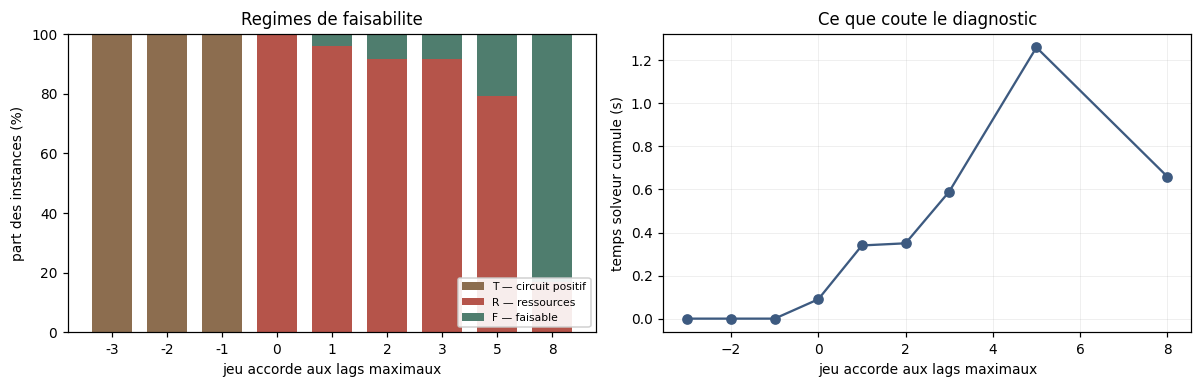

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

parts = tableau[["T", "R", "F"]].div(tableau[["T", "R", "F"]].sum(axis=1), axis=0) * 100
bas = np.zeros(len(parts))
couleurs = {"T": "#8c6d4f", "R": "#b5544a", "F": "#4f7d6e"}
etiquettes = {"T": "T — circuit positif", "R": "R — ressources", "F": "F — faisable"}
for col in ["T", "R", "F"]:
    ax1.bar(parts.index.astype(str), parts[col], bottom=bas,
            color=couleurs[col], label=etiquettes[col], width=0.72)
    bas += parts[col].values
ax1.set_xlabel("jeu accorde aux lags maximaux")
ax1.set_ylabel("part des instances (%)")
ax1.set_title("Regimes de faisabilite")
ax1.legend(fontsize=7, loc="lower right", framealpha=0.9)

ax2.plot(tableau.index, tableau["temps total (s)"], marker="o", color="#3d5a80")
ax2.set_xlabel("jeu accorde aux lags maximaux")
ax2.set_ylabel("temps solveur cumule (s)")
ax2.set_title("Ce que coute le diagnostic")
ax2.grid(alpha=0.25, linewidth=0.5)

plt.tight_layout()
plt.show()

La courbe de droite dit l'essentiel sur le plan pratique. Le temps solveur est **exactement
nul** dans la zone où le diagnostic temporel tranche : le solveur n'y est jamais appelé. Il
grimpe dès que le réseau devient admissible et que la question se déplace vers les ressources.

Le maximum ne tombe pas là où on l'attendrait. Ce n'est pas au passage T → R, à jeu $0$, où le
solveur travaille encore peu : c'est bien plus loin, à jeu $5$, au voisinage de la **seconde**
transition, celle où les instances cessent d'être infaisables. C'est le point où le mélange est
le plus équilibré — ni franchement infaisables, ni confortablement réalisables. Une fois la
majorité des instances devenues réalisables, à jeu $8$, le temps redescend : trouver une
solution est plus facile que prouver qu'il n'en existe aucune.

C'est un argument d'ingénierie autant que de théorie : sur un modèle RCPSP/max, **tester le
circuit positif avant d'appeler le solveur** n'est pas une optimisation cosmétique. Sur ce
balayage, cela retire au solveur le tiers gauche du domaine — 72 instances sur 216, traitées
sans lui — et fournit en prime un témoin lisible là où il n'aurait rendu qu'un mot.

## 7. Une borne gratuite — et ce qu'elle vaut vraiment

Changeons de fil. Un banc d'essai compare des solutions à une **référence**. Quand la référence
est disponible et comparable, l'écart est directement interprétable. Quand elle manque, il faut
bien mesurer quelque chose — sinon la colonne reste vide.

Or deux bornes inférieures s'obtiennent sans aucune référence externe :

- le **chemin critique** $\text{CP}$ — plus long chemin dans le réseau, ressources ignorées ;
- la **borne de charge** $\text{LB}_{\text{ch}} = \max_r \lceil \sum_j d_j \cdot r_{jr} / K_r \rceil$
  — le travail total à écouler sur la ressource la plus sollicitée, précédences ignorées.

Chacune relâche une moitié du problème, et leur maximum est une borne inférieure valide. Un
écart mesuré contre cette borne est plus faible qu'un écart à l'optimum connu — mais il est
**calculable**, **toujours disponible** et **honnête sur son propre statut**.

In [8]:
def borne_de_charge(n, durees, besoins, capacites):
    """max_r plafond(travail total sur r / capacite de r). Ignore les precedences."""
    bornes = []
    for r, cap in enumerate(capacites):
        if cap > 0:
            travail = sum(durees[j] * besoins[j][r] for j in range(n))
            bornes.append(math.ceil(travail / cap))
    return max(bornes) if bornes else 0


def echelle_de_bornes(n, durees, besoins, capacites, succ, budget_s=10.0):
    """Empile les bornes disponibles et situe la solution par rapport a chacune."""
    cpm, _ = chemin_critique(n, durees, succ)
    charge = borne_de_charge(n, durees, besoins, capacites)
    net = reseau_depuis_precedences(n, durees, succ)
    horizon = 3 * sum(durees.values()) + 20
    res = resoudre_rcpsp_max(n, durees, besoins, capacites, net, horizon, budget_s)
    combinee = max(cpm, charge)
    mk = res["makespan"]
    return {
        "chemin_critique": cpm,
        "borne_charge": charge,
        "borne_combinee": combinee,
        "borne_solveur": res["borne_solveur"],
        "makespan": mk,
        "statut": res["statut"],
        "ecart_borne_combinee_pct": round((mk - combinee) / combinee * 100, 1) if mk and combinee else None,
        "borne_active": ("chemin critique" if cpm >= charge else "charge"),
        "secondes": round(res["secondes"], 3),
    }


DENSITES = (0.10, 0.18, 0.28, 0.40, 0.55)

echelles = []
for densite in DENSITES:
    for graine in range(4):
        durees, besoins, capacites, succ, preds = instance_aleatoire(16, graine, densite=densite)
        ligne = echelle_de_bornes(16, durees, besoins, capacites, succ)
        ligne["densite"] = densite
        ligne["graine"] = graine
        echelles.append(ligne)

bornes_df = pd.DataFrame(echelles)[
    ["densite", "graine", "chemin_critique", "borne_charge", "borne_combinee",
     "makespan", "statut", "ecart_borne_combinee_pct", "borne_active"]
]
print(bornes_df.to_string(index=False))

resume = bornes_df.groupby("densite").agg(
    cpm_domine=("borne_active", lambda s: int((s == "chemin critique").sum())),
    ecart_moyen_pct=("ecart_borne_combinee_pct", "mean"),
).round(1)
print("\nQuelle moitie du probleme domine, selon la densite de precedences :")
print(resume.to_string())
serrees = int((bornes_df["ecart_borne_combinee_pct"] == 0).sum())
print(f"\nborne combinee exacte (ecart nul) : {serrees}/{len(bornes_df)} instances")

 densite  graine  chemin_critique  borne_charge  borne_combinee  makespan  statut  ecart_borne_combinee_pct    borne_active
    0.10       0               12            34              34        40 OPTIMAL                      17.6          charge
    0.10       1               11            31              31        34 OPTIMAL                       9.7          charge
    0.10       2               13            31              31        38 OPTIMAL                      22.6          charge
    0.10       3               13            29              29        40 OPTIMAL                      37.9          charge
    0.18       0               20            34              34        40 OPTIMAL                      17.6          charge
    0.18       1               12            31              31        36 OPTIMAL                      16.1          charge
    0.18       2               20            31              31        38 OPTIMAL                      22.6          charge
    0.18

Le tableau de synthèse répond à la question posée : **quelle moitié du problème faut-il
relâcher ?** Aux faibles densités de précédences, la borne de charge domine partout ; le graphe
est trop plat pour qu'une chaîne de tâches pèse quoi que ce soit. En augmentant la densité,
le chemin critique commence à prendre la tête sur quelques instances. La colonne `borne_active`
n'est donc pas une propriété du problème RCPSP en général : c'est une propriété de l'instance,
et la densité de précédences en est le levier. Une seule des deux bornes, prise isolément,
serait très lâche sur toute une moitié du balayage.

Le second chiffre est celui qu'il faut regarder en face : **l'écart à la borne combinée n'est
nul sur aucune de ces instances**. La borne ne touche jamais l'optimum ici. Ce n'est pas une
faiblesse de la borne — c'est une propriété du générateur aléatoire, et le contraste avec la
section suivante est instructif : sur les dix instances PSPLIB observées, le chemin critique
seul atteint l'optimum dans **la moitié des cas**. Un générateur aléatoire ne reproduit pas la
structure d'un benchmark ; les instances de la littérature ont été construites, pas tirées.

Reste la conséquence pratique, valable dans les deux cas. Quand l'écart est strictement positif,
il faut dire ce qu'on mesure : *une distance à une borne calculée*, pas *une distance à
l'optimum connu*. Ce sont deux affirmations différentes, et les confondre est précisément ce
qu'un contrat de provenance doit empêcher.

## 8. Quand la jointure échoue en silence

Reste la question de départ : *que vaut ma référence ?* Un banc d'essai qui charge ses
instances par `sorted(glob(...))[:k]` et qui les rapproche d'une table de références indexée
par nom fait reposer toute sa colonne d'écart sur un accord de chaînes de caractères.

Or l'ordre lexicographique n'est pas l'ordre numérique. Dans les noms PSPLIB, le chiffre `0`
vaut `0x30` et le souligné `_` vaut `0x5F` : `j3010_1` précède donc `j301_1`. Une sélection des
dix premiers fichiers ne renvoie pas la famille de paramètres qu'on croit, et une table clavetée
sur l'autre famille ne trouve alors rien.

L'échec est silencieux : `dict.get(nom)` renvoie `None`, l'écart devient `None`, et la colonne
s'affiche vide sans qu'aucune erreur ne soit levée.

In [9]:
NOMS_PSPLIB = [f"j301_{k}" for k in range(1, 11)] + [f"j3010_{k}" for k in range(1, 11)]
random.Random(7).shuffle(NOMS_PSPLIB)

dix_premiers = sorted(NOMS_PSPLIB)[:10]
print("sorted(...)[:10] renvoie :")
print("  " + ", ".join(dix_premiers))
print(f"\nfamille j301_*  parmi eux : {sum(1 for n in dix_premiers if n.startswith('j301_'))}/10")
print(f"famille j3010_* parmi eux : {sum(1 for n in dix_premiers if n.startswith('j3010_'))}/10")
print(f"\n'j3010_1' < 'j301_1' ? {'j3010_1' < 'j301_1'}   "
      f"(car '0'=0x{ord('0'):02x} precede '_'=0x{ord('_'):02x})")

TABLE_REFERENCES = {f"j301_{k}": 40 + k for k in range(1, 11)}   # clavetee sur l'AUTRE famille
trouvees = sum(1 for n in dix_premiers if n in TABLE_REFERENCES)
print(f"\njointure par nom : {trouvees}/10 references trouvees -> colonne d'ecart vide,"
      f" sans erreur levee")


def cle_tri_psplib(nom):
    """'j3010_2' -> (30, 10, 2). Ordonne par famille puis par parametre, jamais par ASCII.

    Un nom hors convention est range en fin plutot que dilue au milieu : il reste visible.
    """
    famille, _, indice = nom.partition("_")
    tete = famille.lstrip("j")
    for base in ("120", "30", "60", "90"):
        if tete.startswith(base):
            return (int(base), int(tete[len(base):] or 0), int(indice or 0))
    return (10**9, 0, 0)


dix_tries = sorted(NOMS_PSPLIB, key=cle_tri_psplib)[:10]
print("\nsorted(..., key=cle_tri_psplib)[:10] renvoie :")
print("  " + ", ".join(dix_tries))
trouvees_cle = sum(1 for n in dix_tries if n in TABLE_REFERENCES)
print(f"jointure par nom : {trouvees_cle}/10 references trouvees")

sorted(...)[:10] renvoie :
  j3010_1, j3010_10, j3010_2, j3010_3, j3010_4, j3010_5, j3010_6, j3010_7, j3010_8, j3010_9

famille j301_*  parmi eux : 0/10
famille j3010_* parmi eux : 10/10

'j3010_1' < 'j301_1' ? True   (car '0'=0x30 precede '_'=0x5f)

jointure par nom : 0/10 references trouvees -> colonne d'ecart vide, sans erreur levee

sorted(..., key=cle_tri_psplib)[:10] renvoie :
  j301_1, j301_2, j301_3, j301_4, j301_5, j301_6, j301_7, j301_8, j301_9, j301_10
jointure par nom : 10/10 references trouvees


Dix lignes, aucune référence trouvée, aucune exception. C'est le mode de défaillance le plus
coûteux : le programme continue, produit un tableau d'apparence normale, et seule la lecture
attentive d'une colonne de `None` révèle que la comparaison n'a jamais eu lieu.

Le protocole est ici en cause, jamais les auteurs : dans le rendu source, **les dix makespans
publiés sont exacts** — ils ont été recalculés indépendamment pour cet audit et tous confirmés
`OPTIMAL`. Ce qui manque n'est pas un résultat, c'est la garantie qu'une comparaison manquée
se signale.

App-29 a déjà doté CoursIA du premier volet : **refuser** une jointure dont l'identité
structurelle ne correspond pas. Le volet complémentaire est celui-ci : **sur quoi se rabattre
quand la référence manque légitimement ?**

In [10]:
def cle_identite(n, durees, besoins, capacites, succ):
    """Empreinte structurelle : le nom est informatif, l'empreinte est la cle."""
    import hashlib
    charge = json.dumps({
        "n": n,
        "durees": [durees[j] for j in range(n)],
        "besoins": [list(besoins[j]) for j in range(n)],
        "capacites": list(capacites),
        "arcs": sorted((i, j) for i in sorted(succ) for j in succ[i]),
    }, sort_keys=True)
    return hashlib.sha256(charge.encode("utf-8")).hexdigest()[:16]


def evaluer_avec_repli(n, durees, besoins, capacites, succ, makespan, references):
    """Compare a la reference si l'identite concorde ; sinon se rabat sur la borne certifiee.

    Ne renvoie JAMAIS un ecart sans dire a quoi il se rapporte.
    """
    cle = cle_identite(n, durees, besoins, capacites, succ)
    if cle in references:
        ref = references[cle]
        return {"reference": "externe", "valeur": ref, "niveau_de_preuve": "optimum publie",
                "ecart_pct": round((makespan - ref) / ref * 100, 1)}
    cpm, _ = chemin_critique(n, durees, succ)
    charge = borne_de_charge(n, durees, besoins, capacites)
    combinee = max(cpm, charge)
    return {"reference": "borne calculee", "valeur": combinee,
            "niveau_de_preuve": "borne inferieure certifiee (chemin critique / charge)",
            "ecart_pct": round((makespan - combinee) / combinee * 100, 1)}


durees, besoins, capacites, succ, preds = instance_aleatoire(16, 3, densite=0.22)
net = reseau_depuis_precedences(16, durees, succ)
res = resoudre_rcpsp_max(16, durees, besoins, capacites, net, 3 * sum(durees.values()) + 20)
mk = res["makespan"]

cle_vraie = cle_identite(16, durees, besoins, capacites, succ)
for libelle, refs in [
    ("identite connue      ", {cle_vraie: mk}),
    ("identite absente     ", {}),
    ("nom identique, autre structure", {"0" * 16: 999}),
]:
    verdict = evaluer_avec_repli(16, durees, besoins, capacites, succ, mk, refs)
    print(f"{libelle} -> reference={verdict['reference']:15} valeur={verdict['valeur']:>4} "
          f"ecart={verdict['ecart_pct']:>5}%  [{verdict['niveau_de_preuve']}]")

identite connue       -> reference=externe         valeur=  43 ecart=  0.0%  [optimum publie]
identite absente      -> reference=borne calculee  valeur=  29 ecart= 48.3%  [borne inferieure certifiee (chemin critique / charge)]
nom identique, autre structure -> reference=borne calculee  valeur=  29 ecart= 48.3%  [borne inferieure certifiee (chemin critique / charge)]


Le contraste est net. Quand l'identité structurelle concorde, l'écart se rapporte à un optimum
publié. Quand elle manque — pour quelque raison que ce soit, jointure ratée, instance nouvelle,
table incomplète — l'évaluation ne se tait pas : elle se rabat sur une borne calculée et **le
dit** dans le champ `niveau_de_preuve`.

La différence avec une colonne vide n'est pas cosmétique. Une colonne vide n'affirme rien et
n'alerte pas. L'écart de 48,3 % à une borne inférieure certifiée affiché ci-dessus est une
information réelle — faible, puisque la borne est lâche, mais utilisable, et surtout impossible
à confondre avec un écart à l'optimum. Le champ `niveau_de_preuve` porte cette distinction dans
la donnée elle-même, pas seulement dans le commentaire qui l'accompagne.

## 9. Ce que le snapshot source donne à voir

La bibliothèque PSPLIB n'est pas redistribuée par CoursIA. En revanche, les dix instances que
le banc d'essai source sélectionne effectivement ont été identifiées par empreinte SHA-256 et
remesurées pour cet audit avec un modèle indépendant. Les mesures sont reproduites ci-dessous
telles quelles, à titre d'observation datée.

La colonne `optimum` n'est pas une valeur recopiée d'une table publiée : c'est le makespan
**recalculé** pour cet audit, d'où le statut `OPTIMAL` et le temps de résolution portés par
chaque ligne. Les dix lignes ont été rejouées une seconde fois le 2026-09-07, à partir d'un
parseur et d'un modèle réécrits indépendamment : les dix optima et les dix chemins critiques
se reproduisent à l'identique. Ce second passage a en revanche corrigé une **empreinte**
mal transcrite (`j12010_10`, un caractère). L'ironie est instructive et sur le sujet même de
la section précédente : une colonne recopiée à la main dérive, y compris celle dont le rôle
est de détecter la dérive — c'est précisément pourquoi `cle_identite` recalcule l'empreinte
au lieu de lui faire confiance.

In [11]:
OBSERVATIONS_PSPLIB = [
    # instance,        sha256[:16],        chemin critique, optimum recalcule, statut, temps (s)
    ("j30/j3010_1",   "4fae4197791f2ee8",  41,  42, "OPTIMAL", 0.06),
    ("j30/j3010_10",  "5b704056bfd6531d",  37,  41, "OPTIMAL", 0.05),
    ("j30/j3010_2",   "108f260686ec9353",  52,  56, "OPTIMAL", 0.04),
    ("j30/j3010_3",   "de28125e10ed4379",  61,  62, "OPTIMAL", 0.03),
    ("j30/j3010_4",   "5526e62c26ae880e",  53,  58, "OPTIMAL", 0.05),
    ("j60/j6010_1",   "9c400697268fac68",  85,  85, "OPTIMAL", 0.05),
    ("j60/j6010_10",  "11793a5c0a25c3a1",  73,  73, "OPTIMAL", 0.04),
    ("j60/j6010_2",   "bd14308ea049193b",  62,  62, "OPTIMAL", 0.04),
    ("j120/j12010_1", "99dd309553f879c2", 111, 111, "OPTIMAL", 0.07),
    ("j120/j12010_10","6620267bb213583b",  66,  66, "OPTIMAL", 0.08),
]

obs = pd.DataFrame(OBSERVATIONS_PSPLIB,
                   columns=["instance", "sha256_16", "chemin_critique", "optimum", "statut",
                            "temps_verification_s"])
obs["ecart_au_chemin_critique"] = obs["optimum"] - obs["chemin_critique"]
obs["borne_serree"] = obs["ecart_au_chemin_critique"] == 0
print(obs.to_string(index=False))
print()
print(f"instances ou le chemin critique touche deja l'optimum : "
      f"{int(obs['borne_serree'].sum())}/{len(obs)}")
print("Les dix optima ont ete recalcules independamment : les dix concordent avec le rendu source.")
print(f"temps de verification : de {obs['temps_verification_s'].min():.2f} s "
      f"a {obs['temps_verification_s'].max():.2f} s (j120 le plus lourd : "
      f"{obs.loc[obs['instance'] == 'j120/j12010_1', 'temps_verification_s'].iloc[0]:.2f} s)")

      instance        sha256_16  chemin_critique  optimum  statut  temps_verification_s  ecart_au_chemin_critique  borne_serree
   j30/j3010_1 4fae4197791f2ee8               41       42 OPTIMAL                  0.06                         1         False
  j30/j3010_10 5b704056bfd6531d               37       41 OPTIMAL                  0.05                         4         False
   j30/j3010_2 108f260686ec9353               52       56 OPTIMAL                  0.04                         4         False
   j30/j3010_3 de28125e10ed4379               61       62 OPTIMAL                  0.03                         1         False
   j30/j3010_4 5526e62c26ae880e               53       58 OPTIMAL                  0.05                         5         False
   j60/j6010_1 9c400697268fac68               85       85 OPTIMAL                  0.05                         0          True
  j60/j6010_10 11793a5c0a25c3a1               73       73 OPTIMAL                  0.04                 

Deux lectures, qu'il faut tenir séparées.

**Ce que la table établit.** Sur cinq des dix instances effectivement sélectionnées, le chemin
critique **touche déjà l'optimum**. Là, une évaluation par repli sur borne calculée aurait été
aussi informative qu'une comparaison à l'optimum publié : l'écart mesuré aurait été le bon, à
zéro près. Sur les cinq autres, la borne est optimiste de 1 à 5 unités, et le repli l'aurait
signalé comme tel.

**Ce qu'elle n'établit pas.** Que ces cinq instances seraient « faciles », ou que leurs
ressources seraient inactives. Elles ne le sont pas : sur chacune, la capacité disponible est
très inférieure au pic de demande de l'ordonnancement au plus tôt, lequel est donc irréalisable.
Les ressources imposent bel et bien une réorganisation — simplement, elles n'imposent aucun
retard. Le critère « capacité supérieure au pic au plus tôt » est *suffisant* pour garantir que
l'optimum vaut le chemin critique ; il n'est pas *nécessaire*, et ces cinq instances en sont le
contre-exemple.

Enfin, la vitesse de résolution ne s'explique pas par cette coïncidence : les cinq instances où
la borne est lâche se résolvent tout aussi vite. Les deux observations sont indépendantes, et
les rapprocher serait une inférence non fondée.

## 10. Exercices

Trois exercices reprennent chacun un maillon de la chaîne, dans l'ordre où le notebook les a
construits :

1. **`circuit_positif`** — décider la faisabilité temporelle sans calculer les dates
   (section 3, le critère de circuit de poids positif) ;
2. **`poser_exigence_refroidissement`** — traduire une exigence industrielle en arc
   (section 4, le sens de l'arc et le signe du poids) ;
3. **`ma_borne_de_charge`** — écrire la borne qui reste quand la référence manque
   (section 7, le second membre de la hiérarchie de bornes).

Les trois sont livrés **non traités**. Les cellules de vérification comparent votre réponse à
une implémentation de référence et affichent un verdict ; elles ne lèvent aucune exception, un
stub laissé tel quel affiche simplement « non traité ».

In [12]:
# ------------------------------------------------------------------------------
# Exercice 1 — decider la faisabilite temporelle sans calculer les dates.
#
# Ecrire une fonction qui repond True/False a la question : "ce reseau contient-il un
# circuit de poids strictement positif ?". Vous pouvez vous inspirer de la relaxation
# de dates_au_plus_tot, mais sans en renvoyer les dates.
#
# Indice : apres n tours de relaxation sur n noeuds, plus aucune amelioration ne doit
# etre possible si le reseau est faisable.
# ------------------------------------------------------------------------------

def circuit_positif(net):
    """Retourne True s'il existe un circuit de poids strictement positif, False sinon."""
    # TODO : remplacer None par votre implementation
    return None


cas = []
for borne_max in (8, 6, 5, 4, 3, 2):
    n = chaine_de_base()
    n.add_max_lag(1, 3, borne_max)
    attendu = not dates_au_plus_tot(n)[0]
    cas.append((f"lag maximal <= {borne_max}", n, attendu))

reponses = [(lib, circuit_positif(n), att) for lib, n, att in cas]
if all(r is None for _, r, _ in reponses):
    print("Exercice 1 : non traite (la fonction renvoie None).")
else:
    justes = sum(1 for _, r, att in reponses if r == att)
    for lib, r, att in reponses:
        marque = "ok" if r == att else "ecart"
        print(f"  {lib:22} votre reponse={str(r):5} attendu={str(att):5}  {marque}")
    print(f"\nExercice 1 : {justes}/{len(reponses)} cas corrects.")

Exercice 1 : non traite (la fonction renvoie None).


Le point de l'exercice n'est pas l'algorithme, qui tient en quelques lignes, mais ce qu'il
autorise à dire. Une fonction qui répond `True` ici produit une **preuve d'infaisabilité en
temps polynomial** — quelque chose qu'aucun appel à un solveur ne fournit, puisqu'un solveur
qui répond `INFEASIBLE` ne rend pas de certificat vérifiable à la main.

C'est aussi le test qu'il faut placer *avant* le solveur dans tout pipeline RCPSP/max.

In [13]:
# ------------------------------------------------------------------------------
# Exercice 2 — traduire une exigence industrielle en arc.
#
# Exigence : "le controle qualite (tache 3) doit demarrer au plus tard 10 unites de temps
# apres le debut de l'usinage (tache 1), sans quoi la piece refroidit."
#
# Completer la fonction pour qu'elle pose le ou les arcs correspondants sur le reseau.
# Attention au sens de l'arc et au signe du poids.
# ------------------------------------------------------------------------------

def poser_exigence_refroidissement(net, usinage=1, controle=3, delai_max=10):
    """Pose sur net la contrainte s_controle - s_usinage <= delai_max."""
    # TODO : ajouter l'arc adequat a net (une seule ligne suffit)
    return net


essai = chaine_de_base()
avant = len(essai.arcs)
poser_exigence_refroidissement(essai)
apres = len(essai.arcs)

if apres == avant:
    print("Exercice 2 : non traite (aucun arc ajoute).")
else:
    ajoutes = essai.arcs[avant:]
    ok_sens = all(i == 3 and j == 1 for i, j, _ in ajoutes)
    ok_poids = all(d == -10 for _, _, d in ajoutes)
    print(f"  arcs ajoutes      : {ajoutes}")
    print(f"  sens attendu 3->1 : {'ok' if ok_sens else 'a revoir (l arc doit pointer a l envers)'}")
    print(f"  poids attendu -10 : {'ok' if ok_poids else 'a revoir (le poids vaut -delai_max)'}")
    print(f"  circuit cree      : {essai.a_un_circuit()}")
    print(f"  faisable          : {dates_au_plus_tot(essai)[0]}")

Exercice 2 : non traite (aucun arc ajoute).


L'erreur la plus commune consiste à poser `add_min_lag(1, 3, 10)`, qui se lit « au moins 10 »
et non « au plus 10 ». L'arc part alors dans le bon sens, ne crée aucun circuit, et le modèle
reste un RCPSP ordinaire — correct syntaxiquement, faux sémantiquement, et silencieux.

C'est le piège que la formulation généralisée rend possible : les deux écritures se ressemblent
et le solveur accepte les deux.

In [14]:
# ------------------------------------------------------------------------------
# Exercice 3 — la borne qui reste quand la reference manque.
#
# Completer la borne de charge : pour chaque ressource r, le travail total a ecouler vaut
# somme sur j de (duree_j x besoin_jr) ; il faut au moins ce travail divise par la capacite,
# arrondi a l'entier superieur. La borne retenue est le maximum sur les ressources.
# ------------------------------------------------------------------------------

def ma_borne_de_charge(n, durees, besoins, capacites):
    """Retourne la borne inferieure de charge (entier), ou None si non traite."""
    # TODO : remplacer None par votre implementation
    return None


controles = []
for graine in range(6):
    d, bs, cp, sc, _ = instance_aleatoire(14, 100 + graine)
    controles.append((graine, ma_borne_de_charge(14, d, bs, cp),
                      borne_de_charge(14, d, bs, cp)))

if all(v is None for _, v, _ in controles):
    print("Exercice 3 : non traite (la fonction renvoie None).")
else:
    justes = sum(1 for _, v, att in controles if v == att)
    for graine, v, att in controles:
        print(f"  graine {graine} : votre borne={str(v):>5}  attendu={att:>5}"
              f"  {'ok' if v == att else 'ecart'}")
    print(f"\nExercice 3 : {justes}/{len(controles)} cas corrects.")

Exercice 3 : non traite (la fonction renvoie None).


Cette borne ignore complètement les précédences, comme le chemin critique ignore complètement
les ressources. Aucune des deux n'est bonne seule ; leur maximum l'est souvent assez pour
qualifier un résultat quand aucune référence externe n'est disponible.

C'est ce que la section 7 mesurait, et ce sur quoi le contrat de repli de la section 8 s'appuie.

In [15]:
provenance = {
    "notebook": "App-31-RCPSP-Max-Feasibility-Bounds",
    "objet": "RCPSP/max : faisabilite, circuits de poids positif, hierarchie de bornes",
    "source_distillee": {
        "auteurs": ["Arthur Gallier", "Nicolas Naegelen"],
        "projet": "B4 - Ordonnancement industriel",
        "pull_request": 51,
        "commit": "8b91a736",
        "snapshot": "b5f3f0351dbd41f3a76f047cf02e9c93e81192f3",
        "licence": "MIT",
    },
    "environnement": ENV,
    "instances": "generees dans le notebook avec des graines fixes ; aucune instance externe redistribuee",
    "observations_psplib": [
        {"instance": i, "sha256_16": h, "chemin_critique": c, "optimum_recalcule": o,
         "statut": s, "temps_verification_s": t}
        for i, h, c, o, s, t in OBSERVATIONS_PSPLIB
    ],
    "verification_source": "les 10 makespans publies par le banc d'essai source ont ete "
                           "recalcules avec un modele independant : les 10 concordent, tous OPTIMAL",
}
(DATA / "provenance.json").write_text(
    json.dumps(provenance, indent=2, ensure_ascii=False), encoding="utf-8")

regimes.to_csv(DATA / "temporal_regimes.csv", index=False, encoding="utf-8")

echelle = {
    "definition": {
        "chemin_critique": "plus long chemin, ressources ignorees",
        "borne_charge": "max_r plafond(travail total sur r / capacite de r), precedences ignorees",
        "borne_combinee": "max des deux ; borne inferieure valide sans reference externe",
    },
    "instances": echelles,
}
(DATA / "bounds_ladder.json").write_text(
    json.dumps(echelle, indent=2, ensure_ascii=False), encoding="utf-8")

for f in sorted(DATA.iterdir()):
    print(f"  {f.name:24} {f.stat().st_size:>8} octets")

  bounds_ladder.json           6776 octets
  LICENSE                      1129 octets
  provenance.json              3054 octets
  SOURCE.md                    7540 octets
  temporal_regimes.csv         9386 octets


Les trois artefacts portent chacun un niveau de preuve distinct : `provenance.json` fixe
l'identité et l'environnement, `temporal_regimes.csv` conserve la classification et les témoins
de circuit, `bounds_ladder.json` documente la formule de chaque borne à côté de ses valeurs. Un
chiffre séparé de sa définition n'est pas reproductible ; c'est pourquoi les définitions
voyagent avec les données.

## Hommage au projet B4 — l'exercice que le cours différait

Le rendu d'**Arthur Gallier** et **Nicolas Naegelen** a fait ce que `Planners-8-Temporal`
laissait explicitement « en exercice » : confronter un solveur à un benchmark public
d'ordonnancement, et mettre en regard l'exact et l'approché. Ce n'est pas une petite chose. Il
a fallu écrire un parseur `.sm`, modéliser proprement les cumulatives, construire une baseline
génétique dont le croisement préserve les précédences, et faire tourner tout cela sur trois
tailles d'instances.

La vérification indépendante conduite pour cet audit conclut sur ce point sans réserve : **les
dix makespans publiés sont exacts**, tous certifiés `OPTIMAL` par un modèle réécrit de zéro. Le
« j120 résolu en une fraction de seconde », qui pouvait surprendre, est confirmé lui aussi : la
table de la section 9 en donne le temps de vérification, et la plus grosse instance reste sous
le dixième de seconde. Il n'y avait rien à corriger dans ces résultats.

Ce que ce notebook prolonge se situe ailleurs, sur deux points que leur travail rendait
visibles :

- leur section RCPSP/max pose le **bon modèle général**, capable de porter des lags maximaux ;
  App-31 exerce ce que ce modèle rend possible et que la formulation seule ne montre pas — le
  circuit, le témoin, la bascule de complexité ;
- leur banc d'essai fait reposer sa colonne d'écart sur une jointure par nom ; App-31 en tire
  la question de protocole, non pour corriger un chiffre, mais pour que l'absence de référence
  cesse d'être silencieuse.

Leur structure anticipait d'ailleurs plus qu'elle n'exploitait : la section multi-mode existe
déjà côté CP-SAT, prête pour une comparaison exact/approché que la baseline génétique, restée
mono-mode, ne pouvait pas encore fournir. C'est une extension naturelle de leur propre
architecture, pas une lacune.

## Bilan critique — ce que ce notebook autorise à affirmer

### Ce qui est établi

- Un lag maximal s'encode par un **arc inverse** et referme un circuit ; un décalage minimal
  négatif, non. La distinction est structurelle, pas une affaire de signe.
- Un système de contraintes de différences est faisable **si et seulement si** aucun circuit
  n'est de poids strictement positif. Le témoin exhibé se vérifie à la main.
- En RCPSP pur, l'ordonnancement série ne se bloque jamais — 300 instances, zéro échec — parce
  qu'aucune contrainte n'interdit de repousser une tâche. Avec des lags maximaux, cette garantie
  disparaît et la **faisabilité** devient NP-difficile (Bartusch, Möhring, Radermacher, 1988).
- Tester le circuit positif avant d'appeler le solveur supprime tout coût de recherche sur le
  tiers gauche du domaine balayé — 72 instances sur 216, jamais soumises au solveur — et rend un
  diagnostic lisible là où le solveur ne rendrait qu'un mot.
- Chemin critique et borne de charge relâchent chacun une moitié du problème ; **laquelle domine
  dépend de l'instance**, et la densité de précédences en est le levier mesurable.
- Le maximum des deux bornes est exact sur cinq des dix instances PSPLIB observées, et sur
  **aucune** des vingt instances aléatoires du balayage. Un générateur aléatoire ne reproduit pas
  la structure d'un benchmark construit.

### Ce qui n'est pas établi

- Que les cinq instances PSPLIB dont l'optimum touche le chemin critique auraient des ressources
  « inactives » : leur capacité est très inférieure au pic de l'ordonnancement au plus tôt. Les
  ressources y imposent une réorganisation, non un retard.
- Que la coïncidence borne/optimum expliquerait la vitesse de résolution : les instances où la
  borne est lâche se résolvent tout aussi vite. Les deux observations sont indépendantes.
- Aucune performance générale. Les mesures portent sur de petites instances synthétiques, un
  solveur, une machine et des budgets publiés. Elles enseignent un protocole.
- `INFEASIBLE` sous budget fini n'est concluant que si le solveur le déclare ; un budget épuisé
  ne prouve rien.

### Pour aller plus loin

- Étendre le témoin de circuit à un **certificat de fenêtre** : quel sous-ensemble de bornes
  supérieures rend l'instance infaisable, et lequel suffit à la rétablir ?
- Rejouer la baseline métaheuristique en multi-mode, extension que la structure du projet source
  rendait déjà accessible côté modèle.
- Comparer la borne de charge à une borne énergétique par fenêtre, strictement plus forte.